<a href="https://colab.research.google.com/github/HafizRizqi/MachineLearning_2026/blob/main/JS05/JS05_TUGAS01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚌Tugas Lab 1

NAMA : HAFIZ RIZQI HERNANDA
NIM : 244107020154
KELAS : TI - 3C

1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai
k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving voice.csv to voice.csv


In [2]:
# NOMOR 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv('voice.csv')

# Pisahkan fitur dan label
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split data 70% training dan 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Standardisasi
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Membuat model kNN
knn = KNeighborsClassifier(n_neighbors=3)

# Training
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)

# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9768664563617245
Confusion Matrix:
[[440  12]
 [ 10 489]]
Classification Report:
              precision    recall  f1-score   support

      female       0.98      0.97      0.98       452
        male       0.98      0.98      0.98       499

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



Model klasifikasi yang digunakan adalah algoritma K-Nearest Neighbor (kNN) untuk mengklasifikasikan jenis suara menjadi dua kelas, yaitu male dan female. Dataset voice.csv terdiri dari 3168 data dengan 20 fitur numerik. Data dibagi menjadi data training sebesar 70% dan data testing sebesar 30%. Sebelum digunakan pada model kNN, data dilakukan standardisasi menggunakan StandardScaler agar setiap fitur memiliki skala yang sebanding.

In [3]:
# Nomor 2
fitur_terpilih = [
    'meanfun',
    'IQR',
    'Q25',
    'sd',
    'mode',
    'sp.ent',
    'sfm',
    'centroid'
]

X = data[fitur_terpilih]
y = data['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Standardisasi
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model kNN
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9831756046267087


Berdasarkan beberapa percobaan terhadap fitur pada dataset voice.csv, diperoleh kombinasi fitur yang memberikan performa lebih baik, yaitu meanfun, IQR, Q25, sd, mode, sp.ent, sfm, dan centroid. Dengan menggunakan delapan fitur tersebut, model kNN mampu memperoleh akurasi sebesar 98,32% pada data testing dengan k=3. Hasil tersebut lebih tinggi dibandingkan percobaan awal menggunakan seluruh 20 fitur dengan k=3, yang menghasilkan akurasi sekitar 97,69%. Oleh karena itu, delapan fitur tersebut digunakan dalam model akhir.

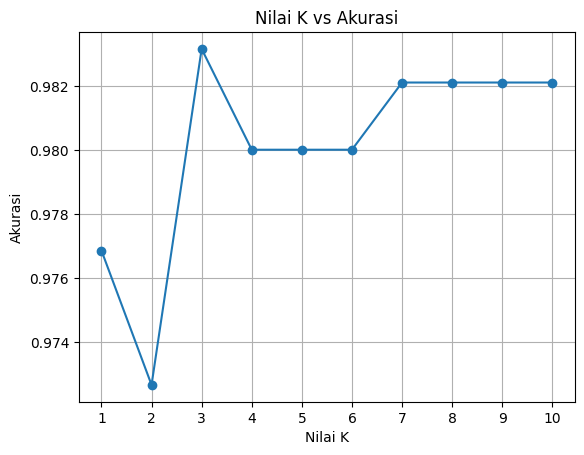

In [4]:
# NOMOR 3

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

acc = []

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    akurasi = model.score(X_test, y_test)
    acc.append(akurasi)

plt.plot(range(1, 11), acc, marker='o')
plt.title('Nilai K vs Akurasi')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Berdasarkan percobaan nilai k dari 1 sampai 10, diperoleh akurasi tertinggi pada k=3, yaitu sebesar 98,32%. Pada nilai k yang lebih besar, akurasi masih berada di sekitar 98%, tetapi tidak melebihi hasil pada k=3. Dari grafik hubungan nilai k dengan akurasi dapat dilihat bahwa performa model mengalami perubahan pada setiap nilai k. Nilai k=3 dipilih karena memberikan akurasi paling tinggi pada percobaan, sehingga digunakan sebagai nilai k pada model klasifikasi akhir.